# UrbanCart Big Data Term Project: Retail Analytics Pipeline

This Jupyter notebook contains the end-to-end data analytics and engineering pipeline for **UrbanCart**, a fictional mid-size online retailer. The pipeline processes raw data, performs extensive cleaning and integration, implements custom NumPy-based analytical algorithms, and answers key business questions with premium visualizations.

## Structure
1. **Phase 1: SQL Data Extraction**: Load and run the 10 SQL queries directly against `ecommerce.db`.
2. **Phase 2: Data Cleaning & Integration (Pandas)**: Standardize date formats, deduplicate customers, handle missing values, cap price outliers, merge the product catalog, and remove duplicate transactions.
3. **Phase 3: Numerical Analysis with NumPy**: Implement RFM segmentation, a collaborative filtering product recommender, linear regression via the normal equation, and a Monte Carlo inventory stockout simulation.
4. **Phase 4: Business Insights & Visualizations**: Answer the 8 core business questions with plots.


In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path
import sys
sys.path.append(os.path.abspath('../src'))

from data_loading import load_all_raw_data
from cleaning import run_cleaning_pipeline
from numpy_analysis import run_numpy_analysis_pipeline, run_rfm_segmentation, run_product_recommendations, run_linear_regression, run_monte_carlo_simulation
from visualizations import generate_all_charts

print("Libraries successfully imported!")


Libraries successfully imported!


## Phase 1: SQL Data Extraction

We extract key retail indicators from `ecommerce.db` by executing the queries from `sql/queries.sql`. Here, we load the results of 4 queries into pandas to verify the connection and show previews.


In [2]:
db_path = '../data/raw/ecommerce.db'
conn = sqlite3.connect(db_path)

# 1. Category Revenue and Order Volume
q1_sql = """
SELECT 
    p.category,
    ROUND(SUM(oi.quantity * oi.unit_price * (1 - oi.discount)), 2) AS total_revenue,
    COUNT(DISTINCT oi.order_id) AS order_count,
    ROUND(SUM(oi.quantity * oi.unit_price * (1 - oi.discount)) / COUNT(DISTINCT oi.order_id), 2) AS average_order_value
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
JOIN orders o ON oi.order_id = o.order_id
WHERE o.status IN ('completed', 'returned')
GROUP BY p.category
ORDER BY total_revenue DESC;
"""
df_category_rev = pd.read_sql_query(q1_sql, conn)
print("Query 1: Category Sales Summary")
display(df_category_rev)

# 2. Top Customers by Lifetime Spend
q2_sql = """
SELECT 
    c.customer_id,
    c.name,
    c.city,
    ROUND(SUM(oi.quantity * oi.unit_price * (1 - oi.discount)), 2) AS lifetime_spend
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.status IN ('completed', 'returned')
GROUP BY c.customer_id, c.name, c.city
ORDER BY lifetime_spend DESC
LIMIT 5;
"""
df_top_custs = pd.read_sql_query(q2_sql, conn)
print("\nQuery 2: Top 5 Customers")
display(df_top_custs)

# 3. Month-over-Month Revenue
q3_sql = """
WITH MonthlyRevenue AS (
    SELECT 
        STRFTIME('%Y-%m', o.order_date) AS order_month,
        SUM(oi.quantity * oi.unit_price * (1 - oi.discount)) AS monthly_revenue
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.status IN ('completed', 'returned')
      AND o.order_date >= '2023-01-01'
    GROUP BY order_month
)
SELECT 
    order_month,
    ROUND(monthly_revenue, 2) AS monthly_revenue,
    ROUND(LAG(monthly_revenue) OVER (ORDER BY order_month), 2) AS prev_month_revenue
FROM MonthlyRevenue
ORDER BY order_month
LIMIT 5;
"""
df_mom = pd.read_sql_query(q3_sql, conn)
print("\nQuery 3: MoM Revenue (First 5 Months of 2023)")
display(df_mom)

# 4. Age Group Analysis (Leadership Custom Query)
q10_sql = """
WITH AgeGroups AS (
    SELECT 
        o.order_id,
        CASE 
            WHEN c.age IS NULL THEN 'Unknown'
            WHEN c.age < 25 THEN 'Under 25'
            WHEN c.age BETWEEN 25 AND 40 THEN '25-40'
            WHEN c.age BETWEEN 41 AND 60 THEN '41-60'
            ELSE 'Over 60'
        END AS age_group
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
),
RevenueAndItems AS (
    SELECT 
        ag.age_group,
        COUNT(DISTINCT ag.order_id) AS total_orders,
        SUM(oi.quantity * oi.unit_price * (1 - oi.discount)) AS gross_revenue
    FROM order_items oi
    JOIN AgeGroups ag ON oi.order_id = ag.order_id
    GROUP BY ag.age_group
)
SELECT 
    age_group,
    total_orders,
    ROUND(gross_revenue, 2) AS net_revenue
FROM RevenueAndItems
ORDER BY net_revenue DESC;
"""
df_age_groups = pd.read_sql_query(q10_sql, conn)
print("\nQuery 10: Sales Distribution by Customer Age Group")
display(df_age_groups)

conn.close()


Query 1: Category Sales Summary


,category,total_revenue,order_count,average_order_value
0,Books & Media,2675787.17,2096,1276.62
1,Beauty & Health,2197340.08,2044,1075.02
2,Apparel,1216936.44,2047,594.50
3,Electronics,1165891.61,2044,570.40
4,Sports & Outdoors,1152314.74,1982,581.39
5,Home & Kitchen,982681.27,2101,467.72



Query 2: Top 5 Customers


,customer_id,name,city,lifetime_spend
0,611,Tara Holmes,Sydney,145169.05
1,689,Misty Mcguire,Toronto,107213.91
2,1259,Matthew Perez,Los Angeles,94853.31
3,1217,Virginia Hernandez,Paris,77530.81
4,528,Brent Hopkins,Vancouver,73939.51



Query 3: MoM Revenue (First 5 Months of 2023)


,order_month,monthly_revenue,prev_month_revenue
0,2023-01,176013.78,NaN
1,2023-02,210639.09,176013.78
2,2023-03,183832.27,210639.09
3,2023-04,142689.92,183832.27
4,2023-05,385881.88,142689.92



Query 10: Sales Distribution by Customer Age Group


,age_group,total_orders,net_revenue
0,41-60,2947,4258948.94
1,25-40,2210,3382637.58
2,Over 60,2031,2832303.96
3,Under 25,1306,1888782.53
4,Unknown,506,716422.36


## Phase 2: Data Cleaning & Integration (Pandas)

We run the data cleaning pipeline defined in `src/cleaning.py` to reconcile customer attributes, product catalogs, resolve duplicate transactions, and apply inventory levels. This exports cleaned datasets to `data/processed/`.


In [3]:
stats = run_cleaning_pipeline('../data')
print(f"Cleaning Pipeline finished!")
print(f"- Price outliers capped: {stats['outliers_count']}")
print(f"- Exact duplicate order items removed: {stats['dedup_stats']['duplicates_removed']}")
print(f"- Out-of-range ratings corrected: {stats['invalid_ratings_count']}")


--- Phase 2 Cleaning Finished ---
Cleaned Customers shape: (2500, 9)
Cleaned Products shape: (300, 7)
Cleaned Order Items shape: (20176, 6)
Cleaned Orders shape: (9000, 5)
Cleaned Reviews shape: (3983, 6)
Cleaned Web Sessions shape: (12000, 6)
Cleaning Pipeline finished!
- Price outliers capped: 3
- Exact duplicate order items removed: 186
- Out-of-range ratings corrected: 41


## Phase 3: Numerical Analysis with NumPy

We execute the custom-coded NumPy mathematical models: RFM customer segmentation, collaborative similarity recommendation, linear regression via the normal equation, and the Monte Carlo stockout simulation.


In [4]:
analysis_results = run_numpy_analysis_pipeline('../data/processed')
print("NumPy Calculations Finished!")


--- Phase 3 NumPy Analytical Methods Finished ---
RFM customer scores generated: 2500
Recommendations generated for sample customer IDs: [10, 20, 30, 40, 50]
Regression completed: intercept=133701.20, slope=7116.51, R2=0.8493
Product 250 MC Simulation: stockout_prob=0.0%, reorder_point=6.9
Product 136 MC Simulation: stockout_prob=0.0%, reorder_point=7.3
Product 211 MC Simulation: stockout_prob=0.0%, reorder_point=6.5
NumPy Calculations Finished!


### 1. RFM Segmentation Model

**Mathematical Formulas**:
* **Recency ($R_i$)**: $R_i = t_{max} - t_{last, i}$
* **Frequency ($F_i$)**: $F_i = \sum I(\text{orders by customer } i)$
* **Monetary Value ($M_i$)**: $M_i = \sum_{j \in \text{items}_i} q_j \cdot p_j \cdot (1 - d_j)$

We calculate quintiles manually on these vectors via `np.percentile` and combine them into a score between 3 and 15.


In [5]:
df_rfm = pd.read_csv('../data/processed/customer_rfm_scores.csv')
print("RFM Segment Counts:")
display(df_rfm['rfm_segment'].value_counts())
print("\nChampions Sample:")
display(df_rfm[df_rfm['rfm_segment'] == 'Champions'].head(5))


RFM Segment Counts:


rfm_segment
Champions              946
Loyal Customers        703
Potential Loyalists    368
At Risk                294
Lost Customers         189
Name: count, dtype: int64


Champions Sample:


,customer_id,recency,frequency,monetary,R_score,F_score,M_score,rfm_score,rfm_segment
1,2,79,3,3200.8345,5,4,4,13,Champions
2,3,279,6,5534.0970,3,5,5,13,Champions
10,11,131,4,3296.6220,5,5,4,14,Champions
11,12,384,4,3659.6265,3,5,4,12,Champions
12,13,149,3,3749.9345,4,4,4,12,Champions


### 2. Cosine Similarity & Collaborative Filtering Recommender

**Mathematical Formula**:
$$\text{similarity}(A, B) = \frac{A \cdot B}{\|A\|_2 \|B\|_2} = \frac{\sum A_k B_k}{\sqrt{\sum A_k^2} \sqrt{\sum B_k^2}}$$

We compute the collaborative similarity matrix and score customer-item interests by projecting past purchases.


In [6]:
df_recs = pd.read_csv('../data/processed/sample_recommendations.csv')
print("Sample Customer Product Recommendations:")
display(df_recs)


Sample Customer Product Recommendations:


,customer_id,purchased,recommended
0,10,"38, 238, 260","179, 267, 218"
1,20,"24, 25, 46, 227, 291, 298","286, 199, 245"
2,30,"8, 87, 91, 174, 176, 208, 233, 295, 297","121, 5, 95"
3,40,"67, 86, 117","240, 107, 164"
4,50,169,"134, 168, 9"


### 3. Linear Regression via the Normal Equation

**Mathematical Formula**:
$$\beta = (X^T X)^{-1} X^T y$$
$$R^2 = 1 - \frac{SS_{residual}}{SS_{total}} = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

We predict monthly sales using month index as the independent variable.


In [7]:
df_reg = pd.read_csv('../data/processed/regression_coefficients.csv')
print("Regression Coefficients:")
display(df_reg)
print(f"\nRegression R^2: {analysis_results['regression']['r2']:.4f}")


Regression Coefficients:


,parameter,coefficient
0,intercept (beta_0),133701.202416
1,slope (beta_1),7116.507888



Regression R^2: 0.8493


### 4. Monte Carlo Inventory Stockout Simulation

We run 5,000 trials for each product to estimate the probability of stockout under demand uncertainty during a 30-day replenishment lead time. We calculate recommended reorder points at the 95th percentile.


In [8]:
df_mc = pd.read_csv('../data/processed/monte_carlo_stockout_stats.csv')
print("Monte Carlo Simulation Summary:")
display(df_mc)


Monte Carlo Simulation Summary:


,product_id,product_name,initial_stock,mean_daily_demand,std_daily_demand,stockout_probability,ci_lower,ci_upper,reorder_point
0,250,Discover Haircare,245,0.061187,0.329522,0.0,0.0,0.0,6.936248
1,136,Watch Footwear,458,0.064840,0.345085,0.0,0.0,0.0,7.278509
2,211,Everyone Skincare,235,0.063014,0.303183,0.0,0.0,0.0,6.522922


## Phase 4: Business Insights & Visualizations

Below are the premium charts representing key analytical insights. We display the generated images directly.



Chart 1: RFM Segment Revenue Contribution


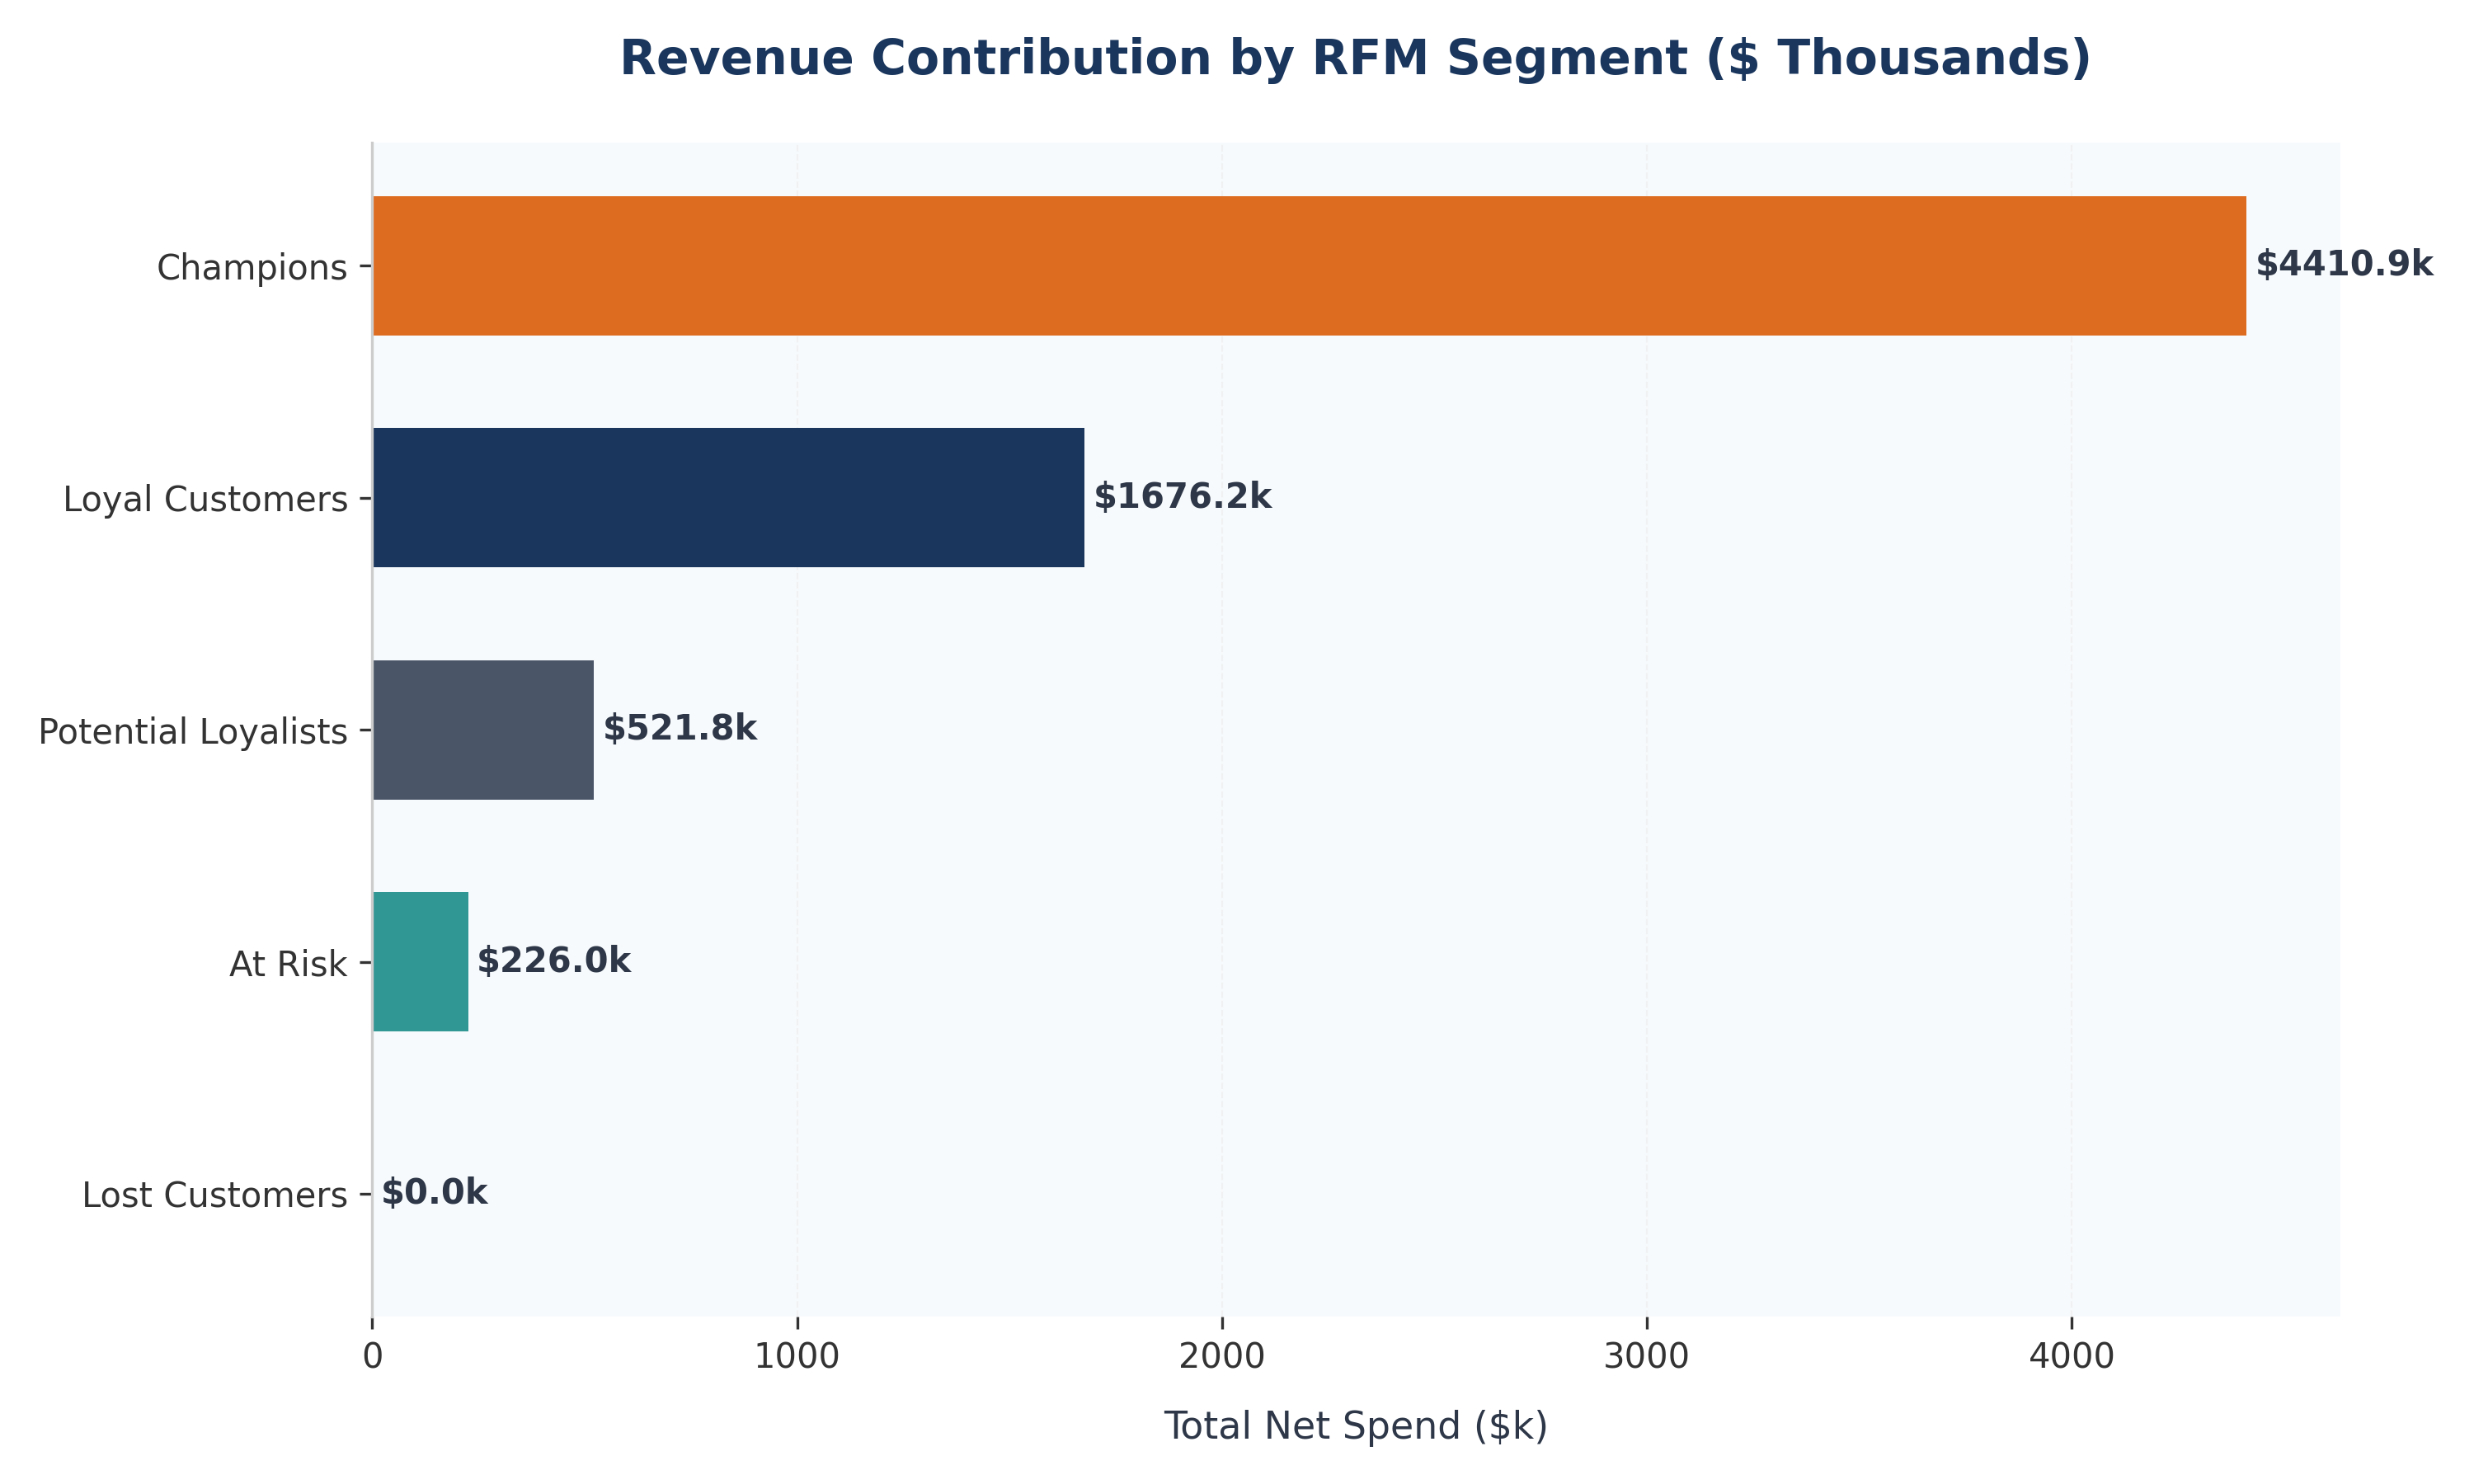


Chart 2: MoM Revenue Trend and Seasonality


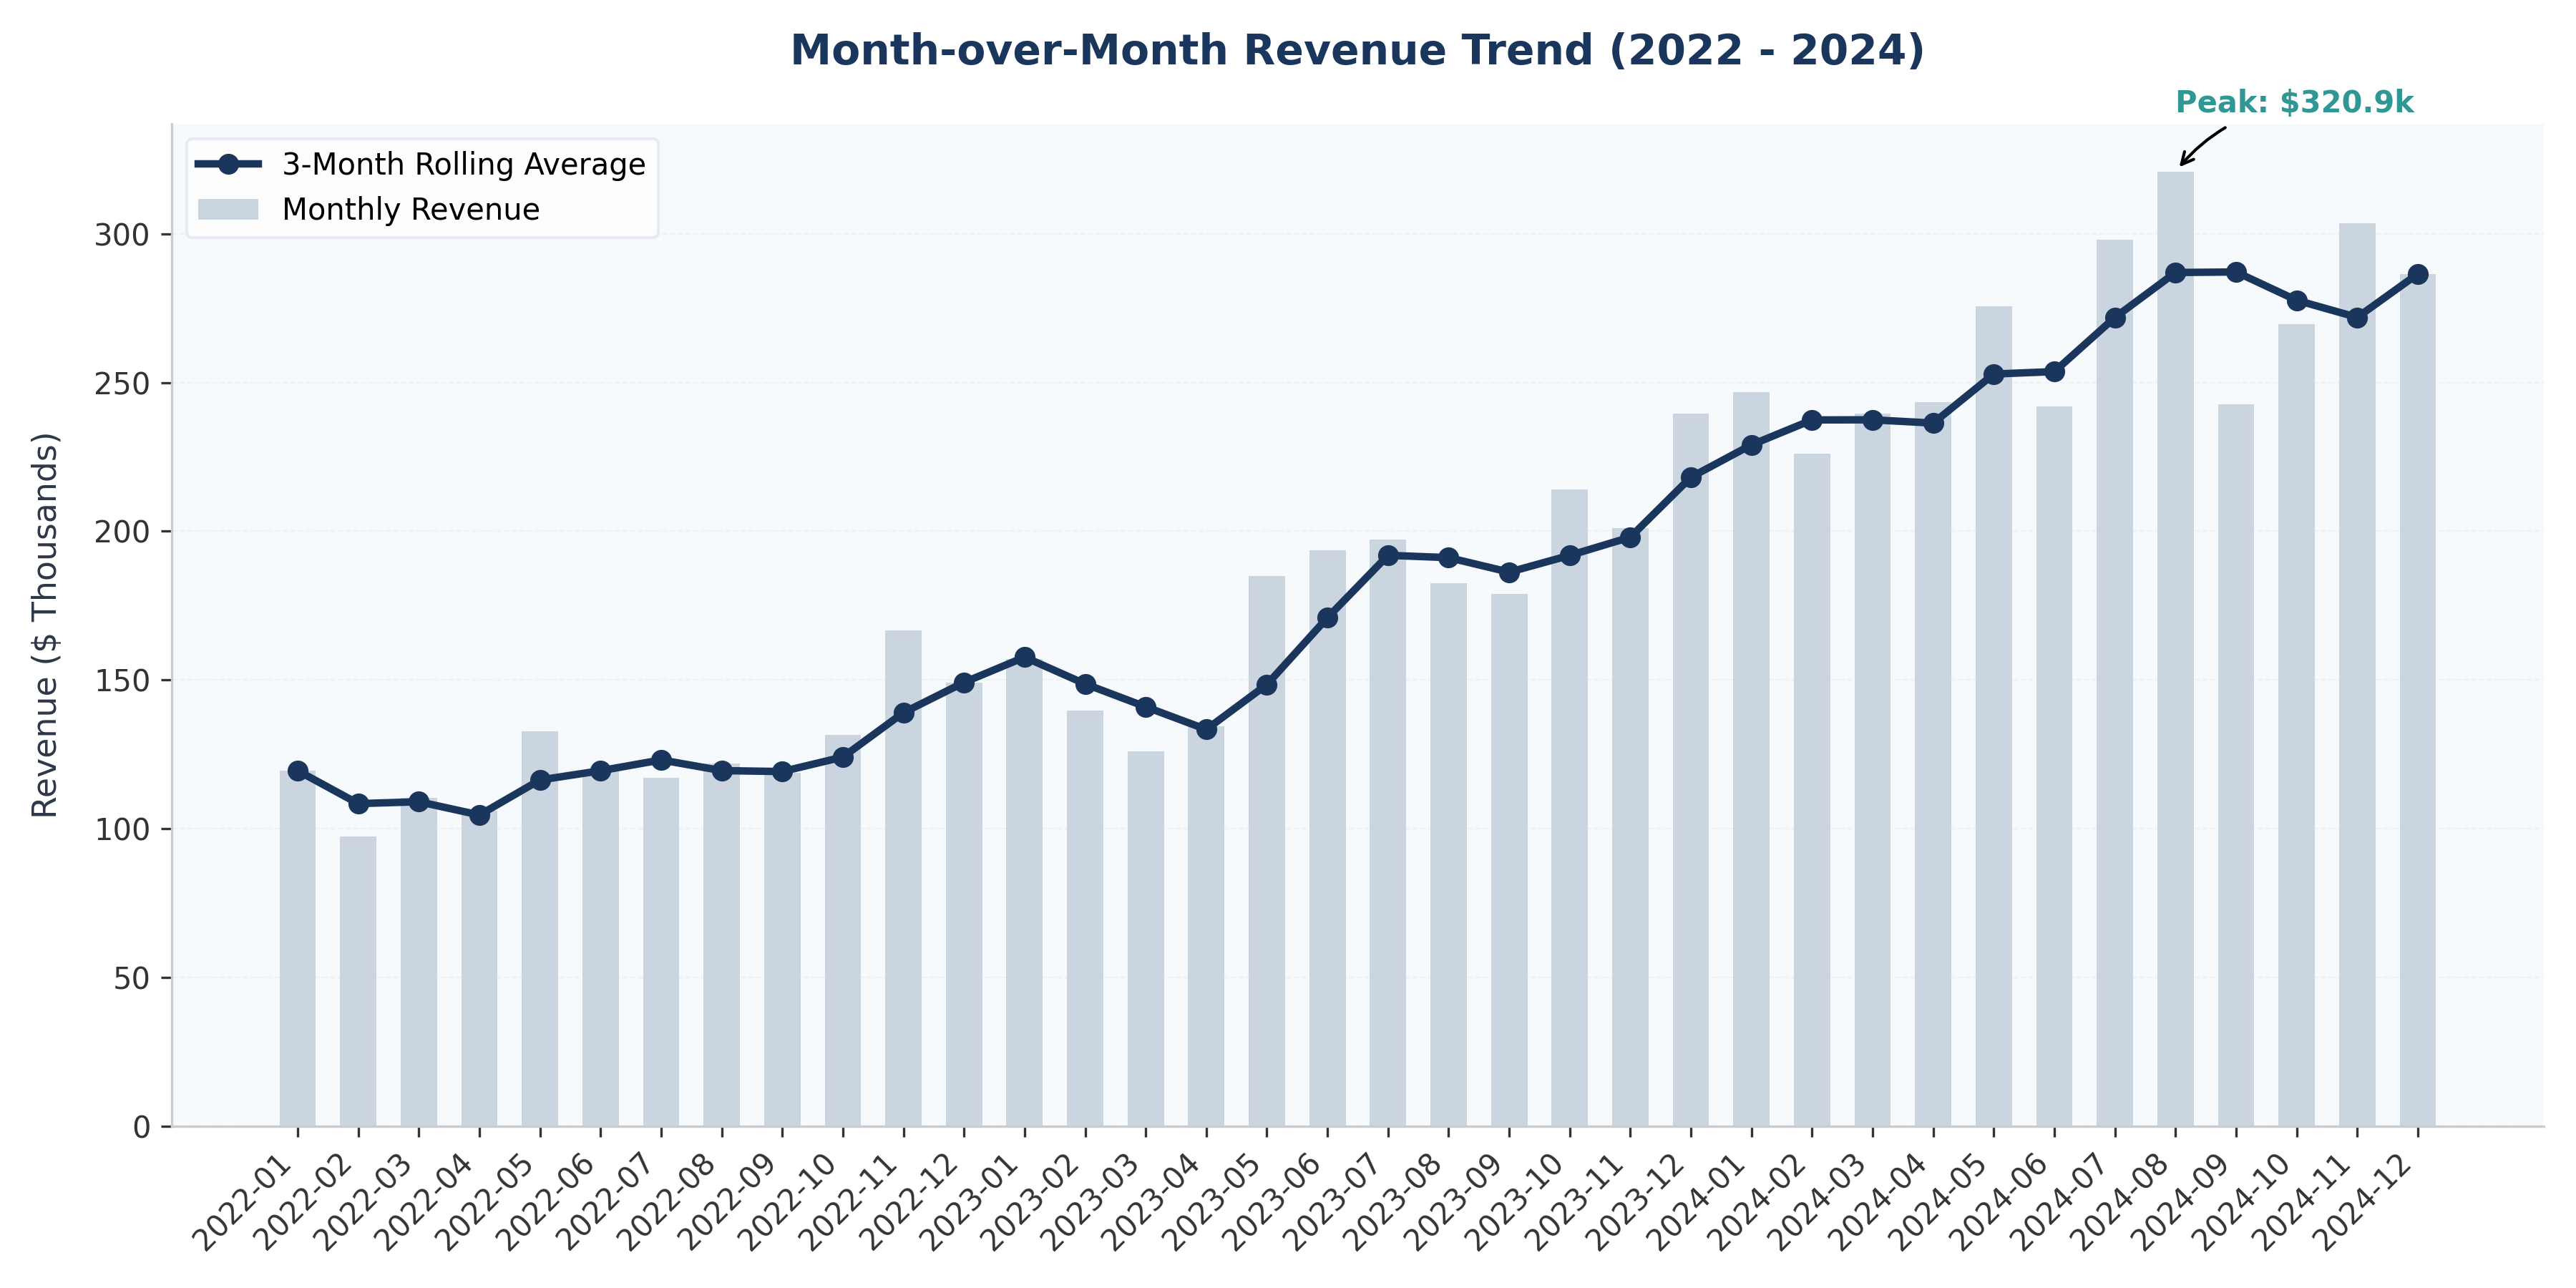


Chart 3: Effective Profit Margin by Category


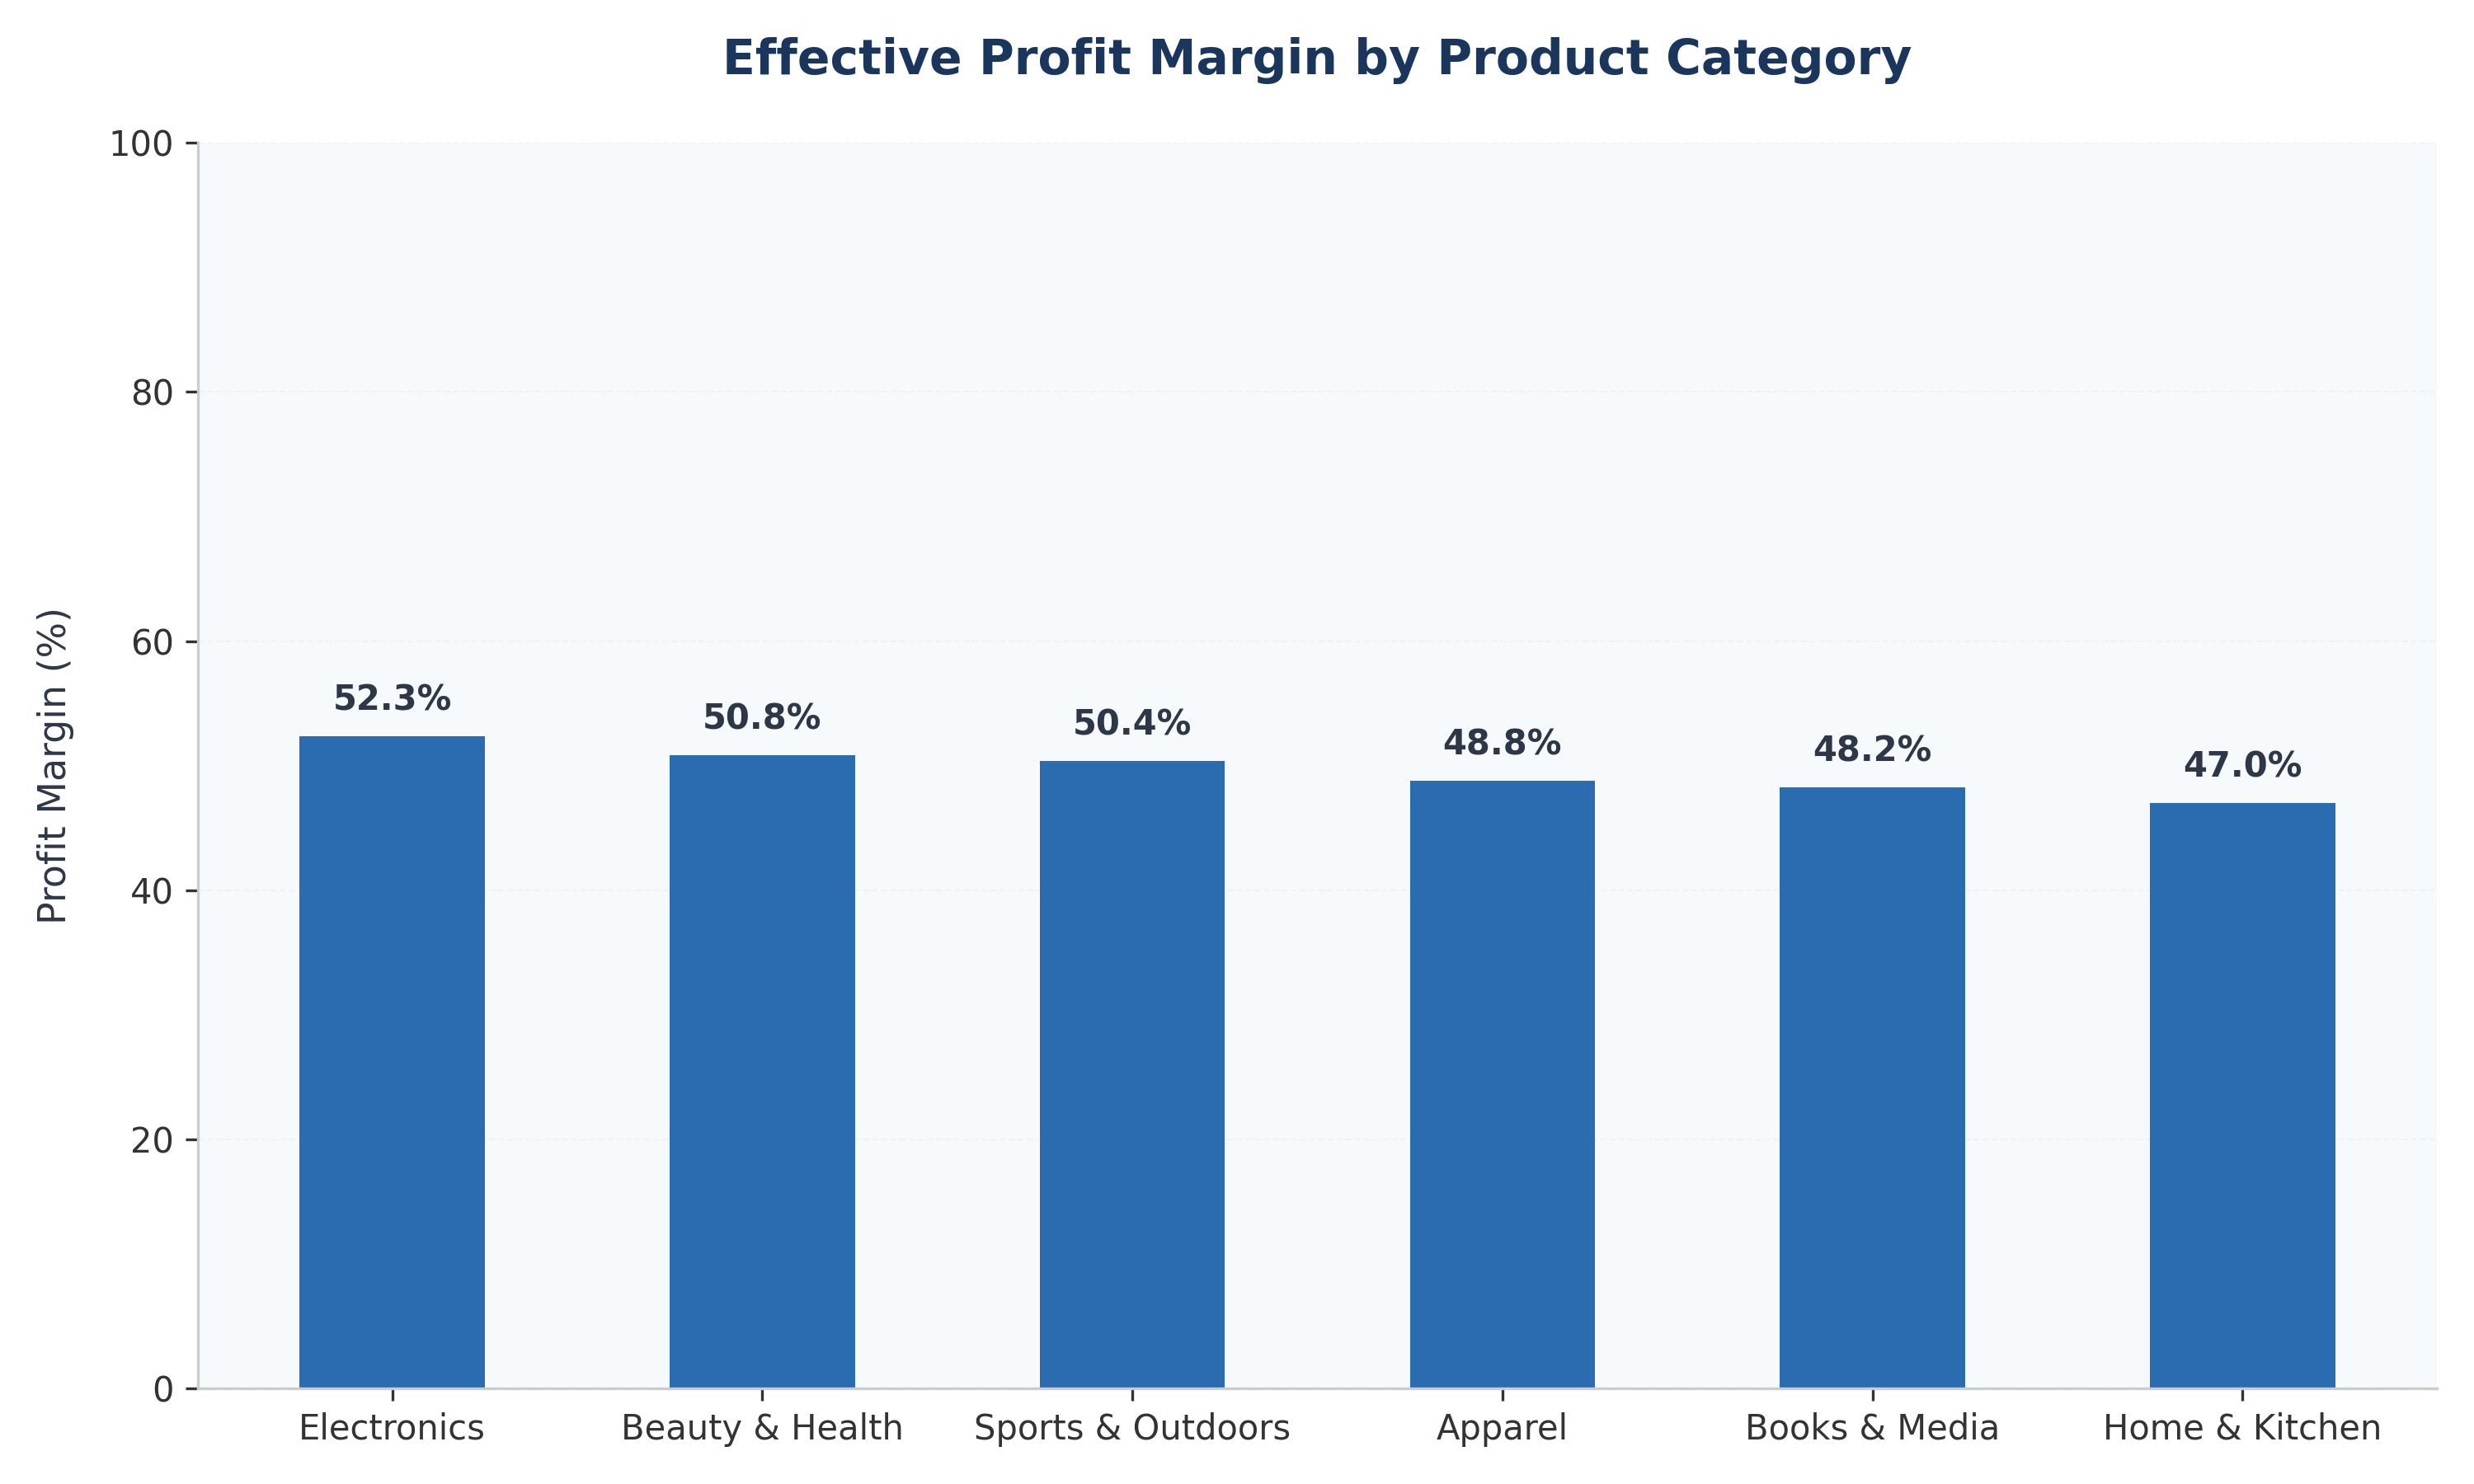


Chart 4: Review Ratings vs. Repeat Purchase Rates


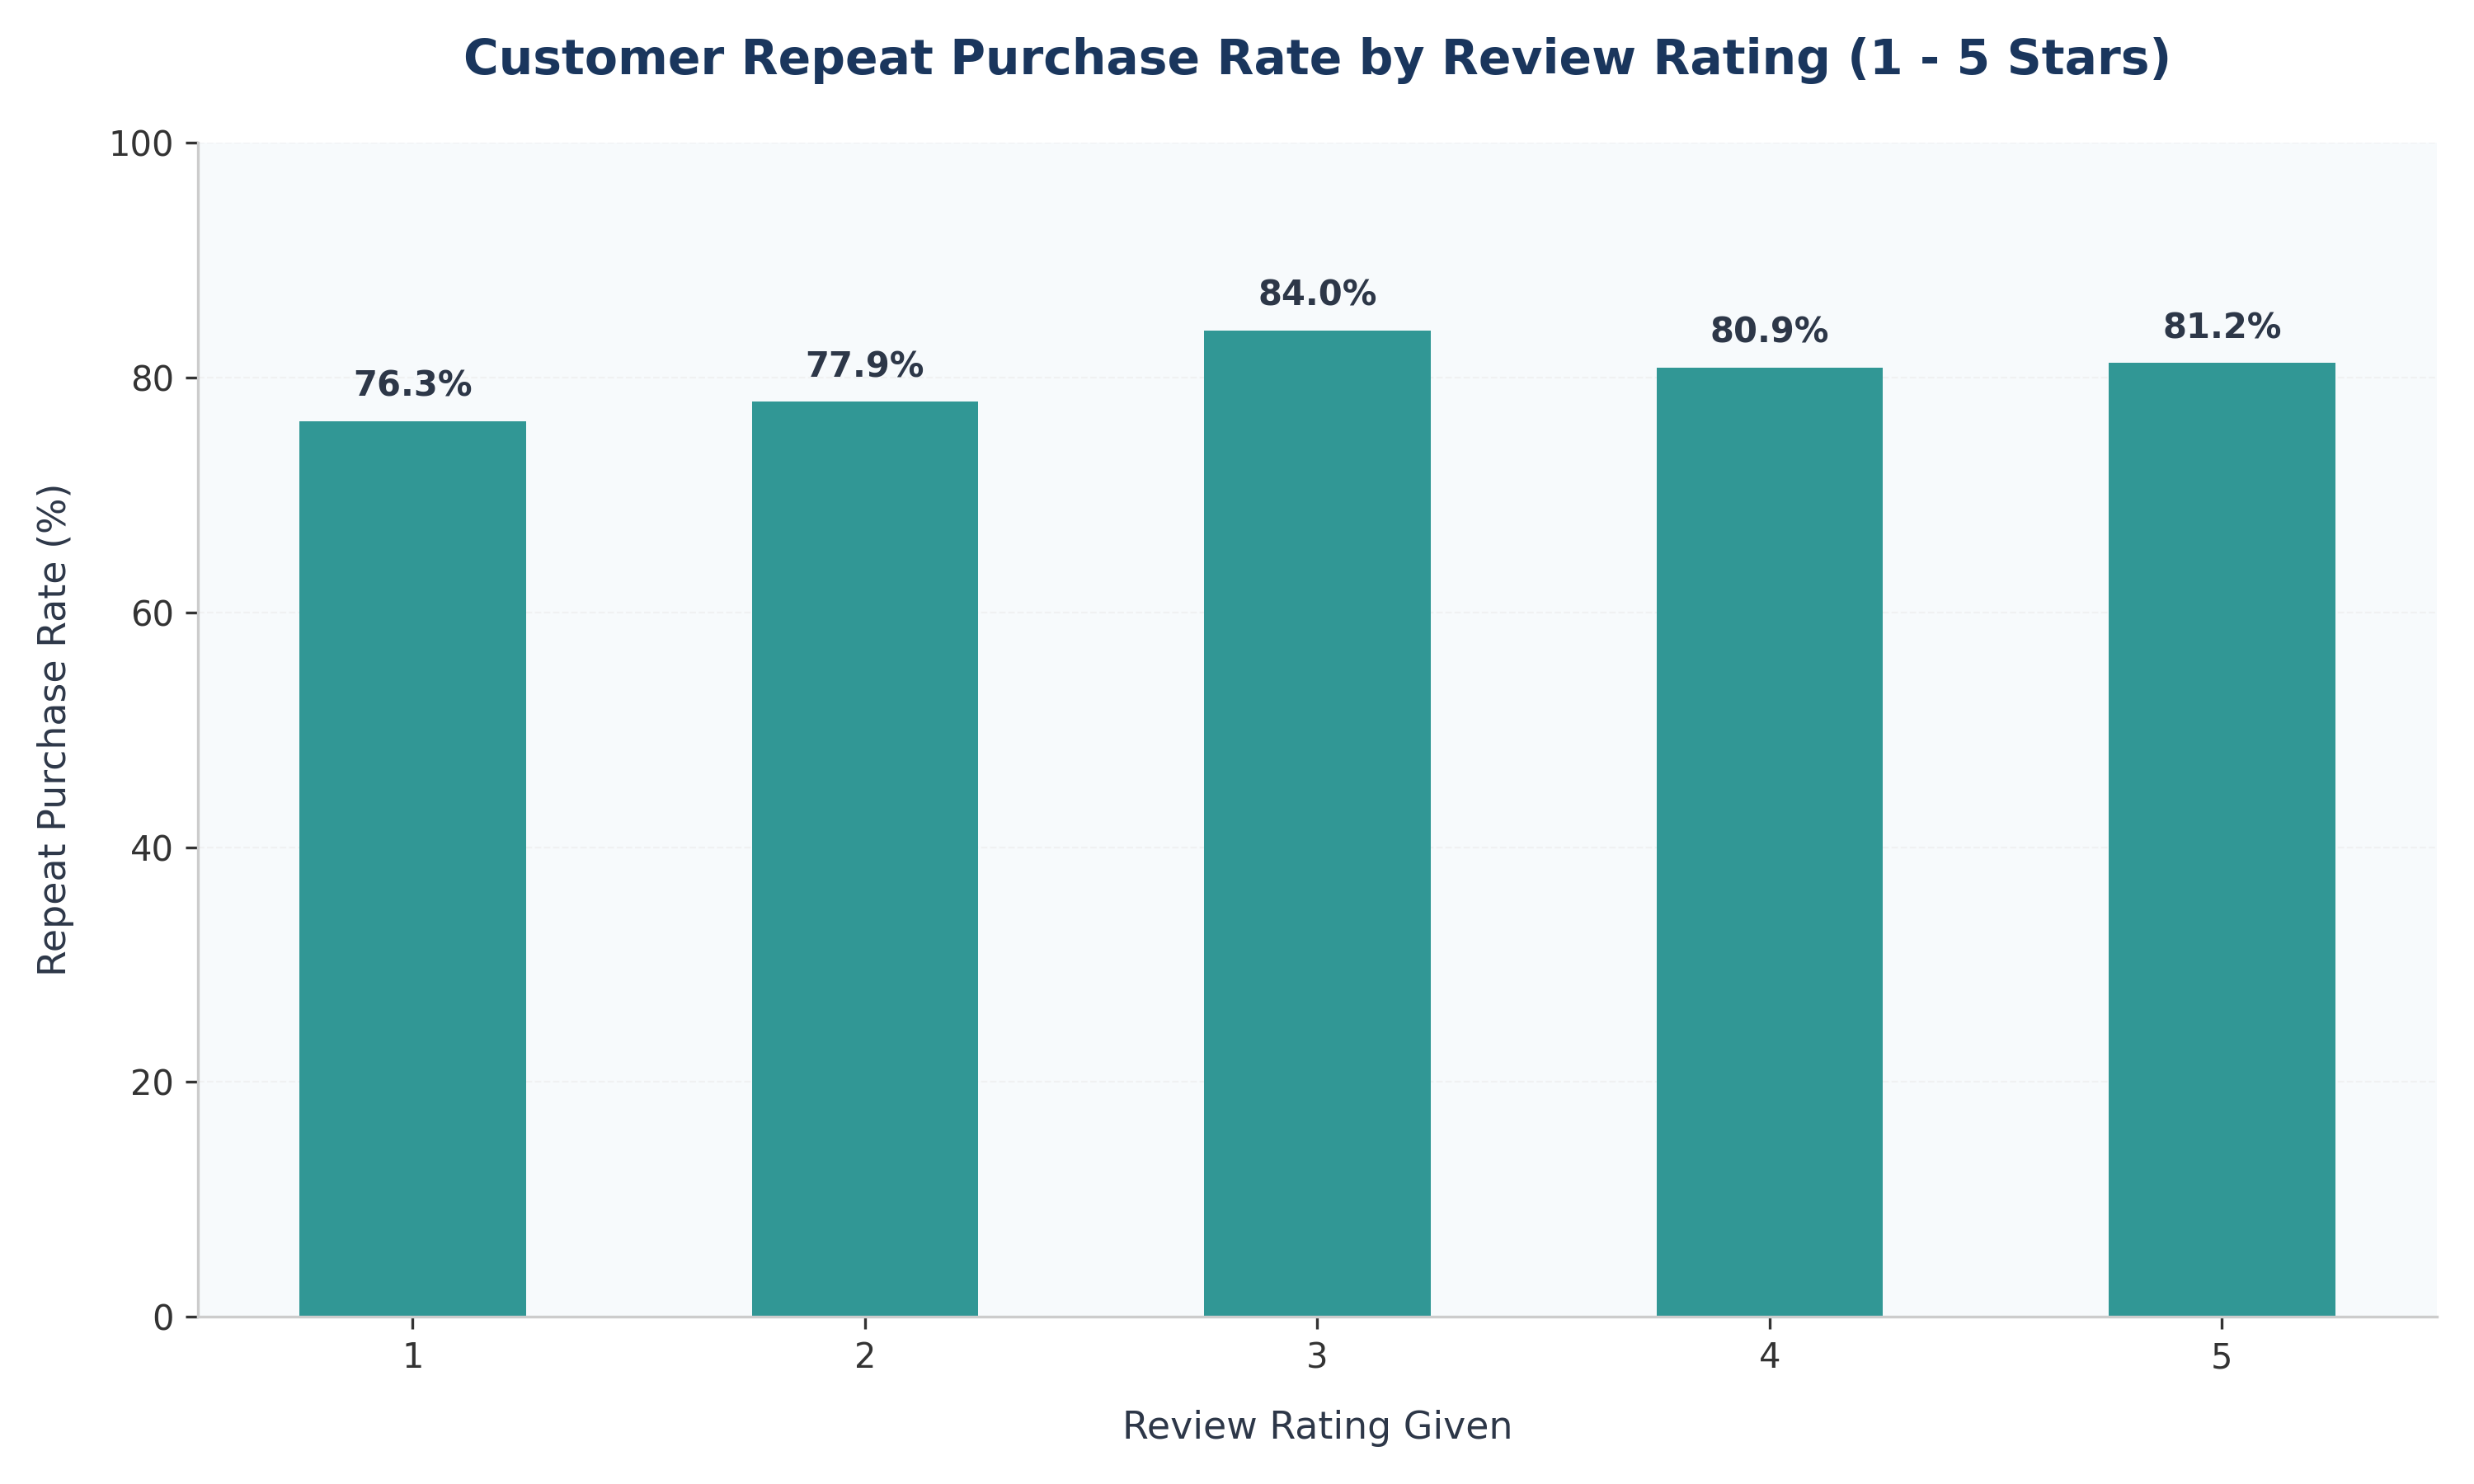


Chart 5: Device Type & Country Conversion Rate Heatmap


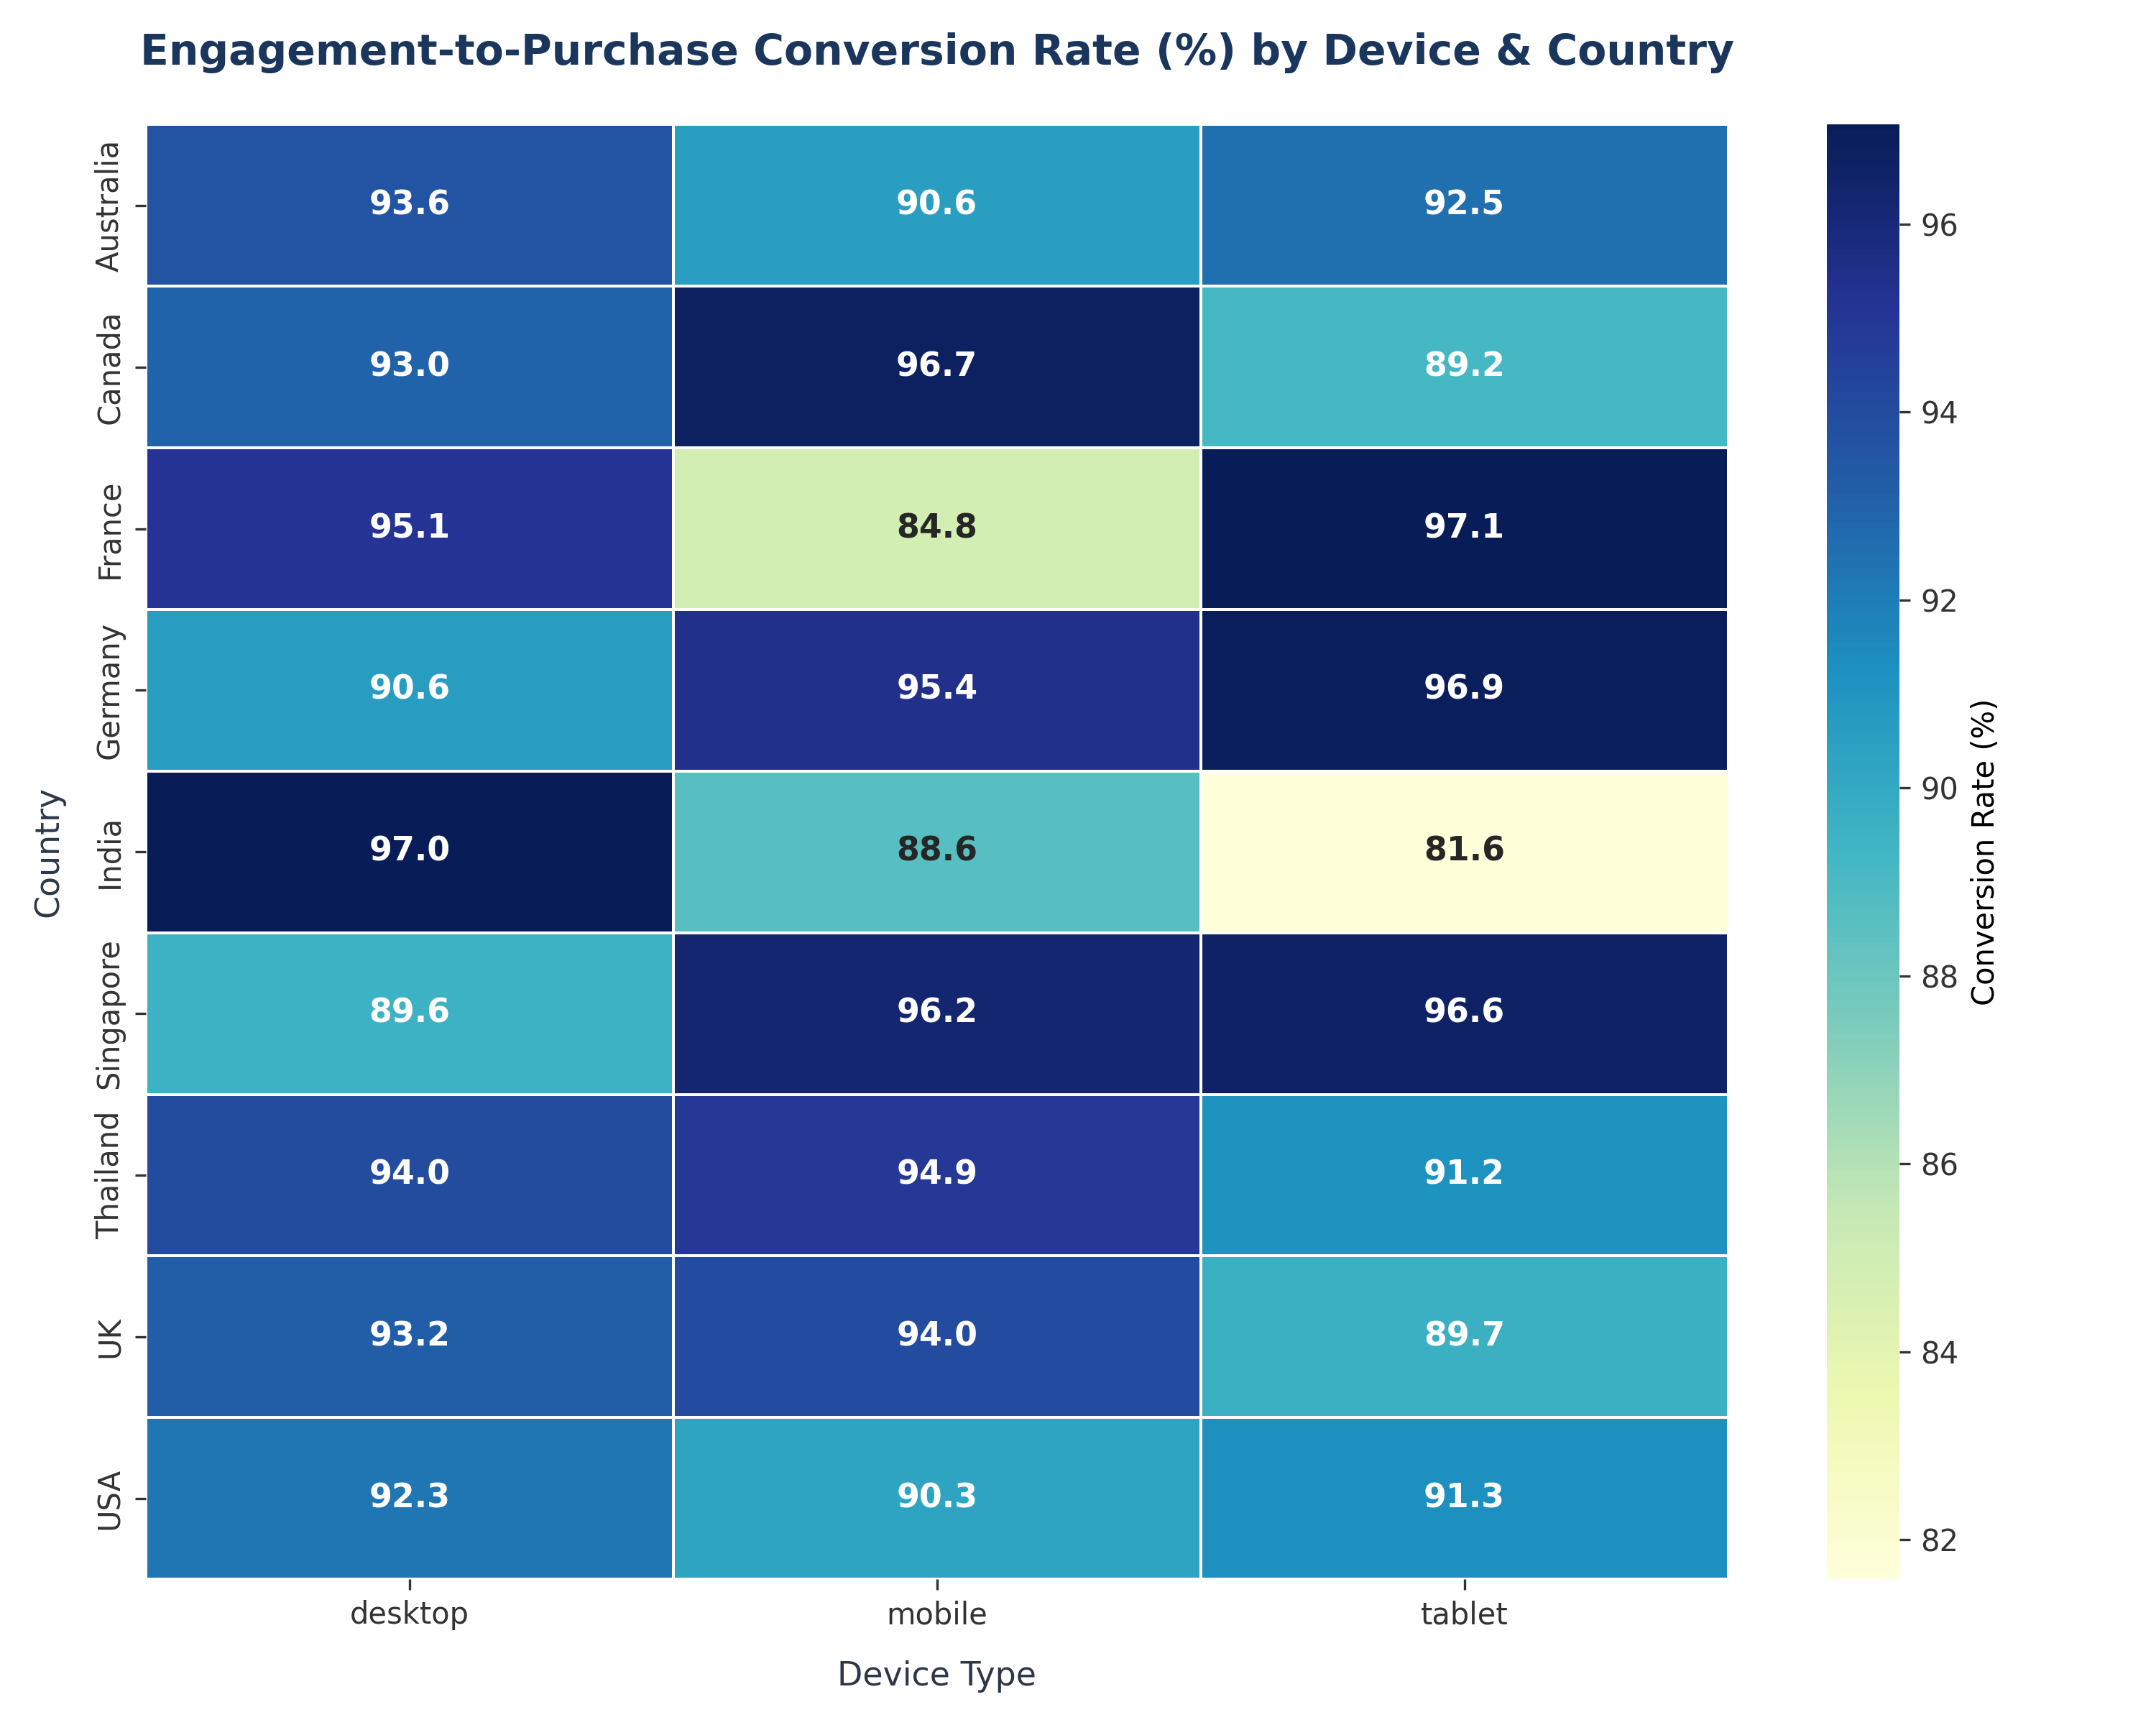


Chart 6: Revenue Forecasting with Uncertainty Bands


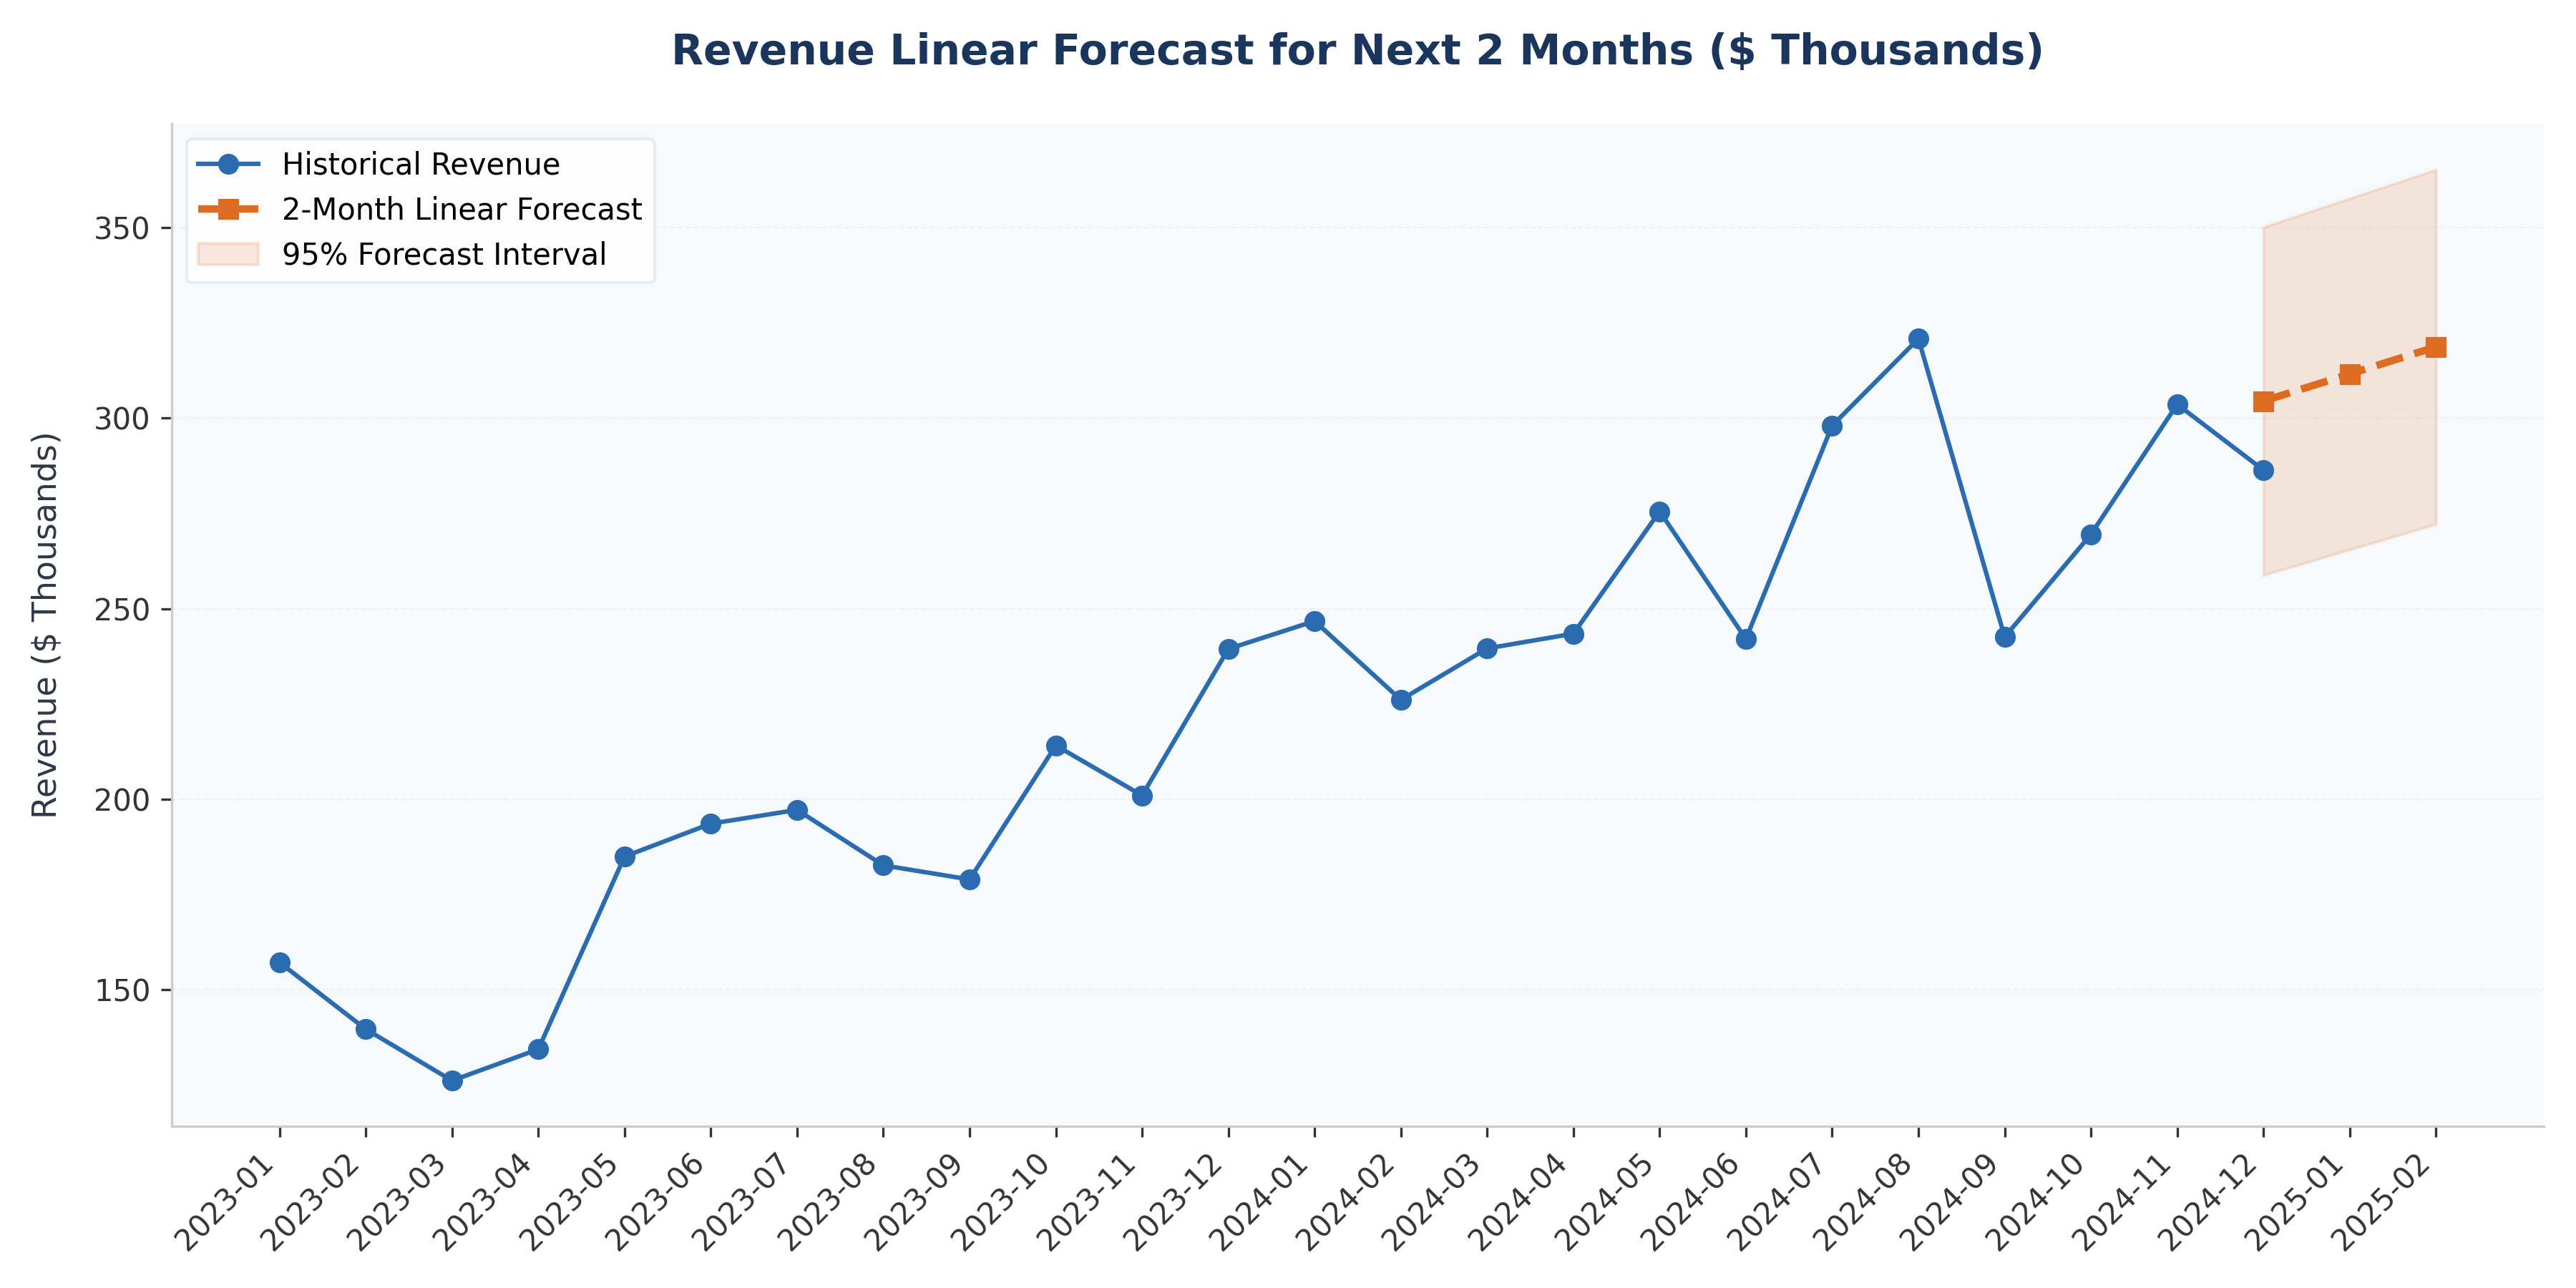


Chart 7: Monte Carlo Stockout Demand Distributions


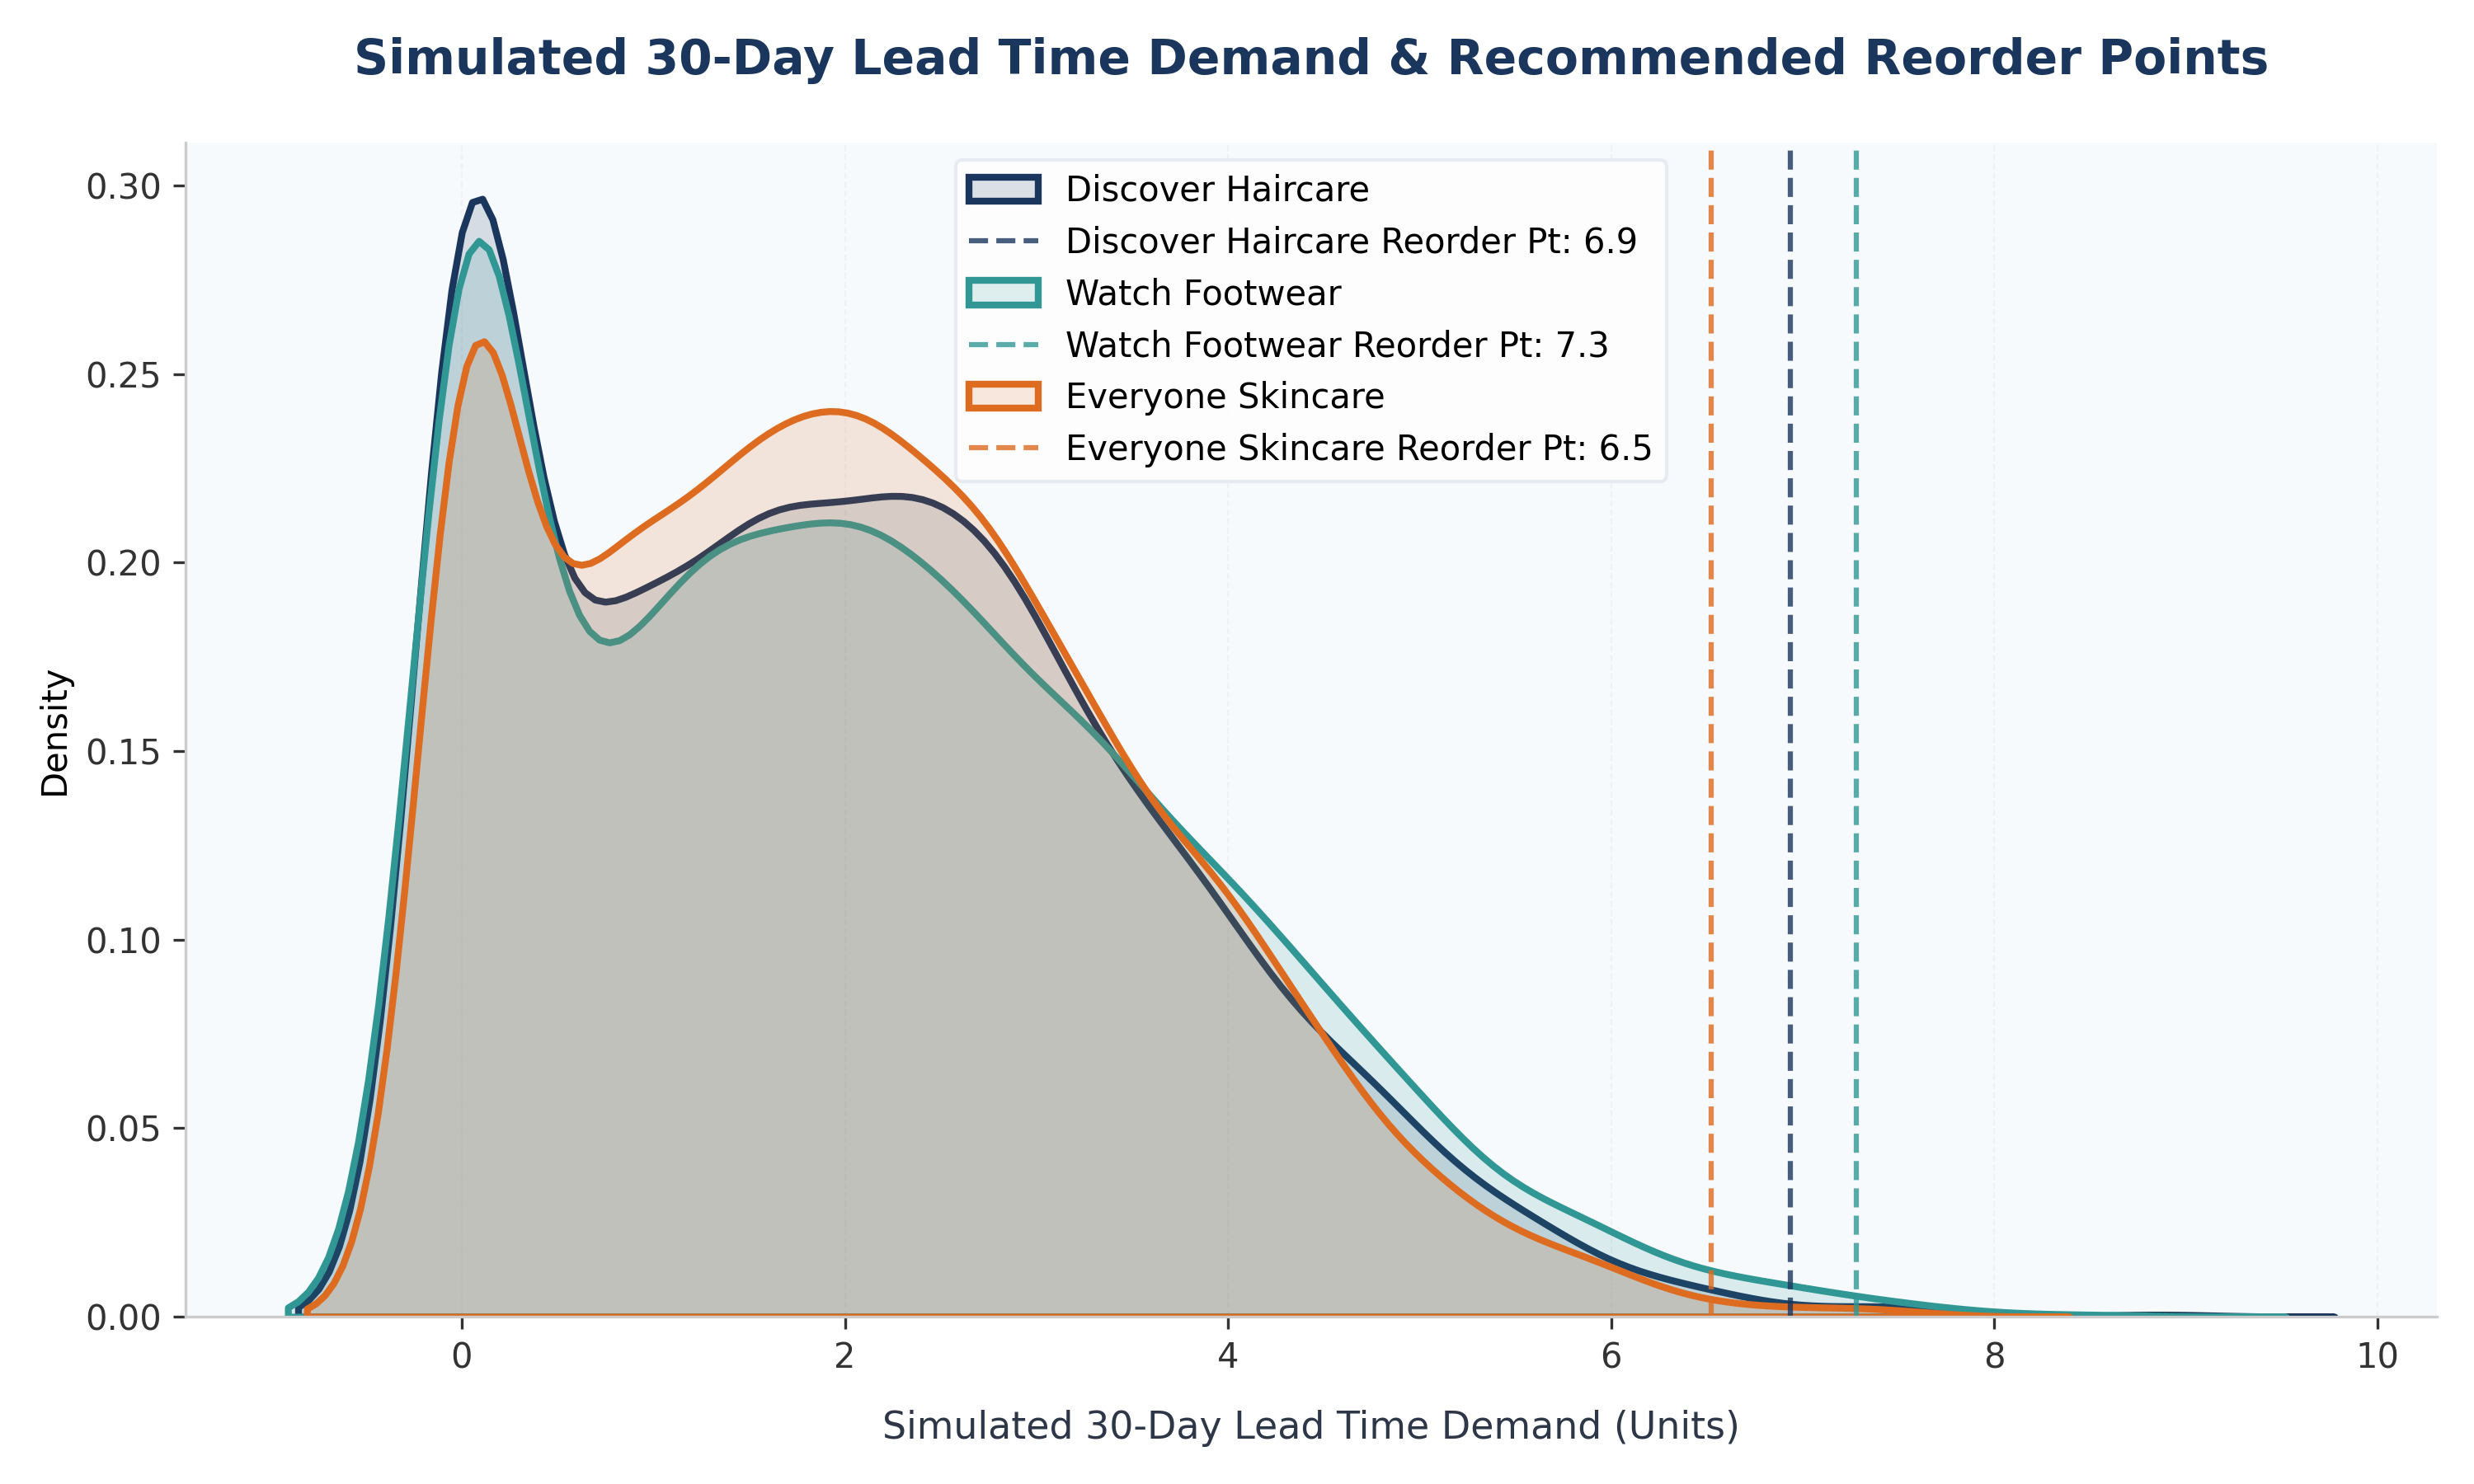


Chart 8: Data-Quality Impact (Raw vs Cleaned Data)


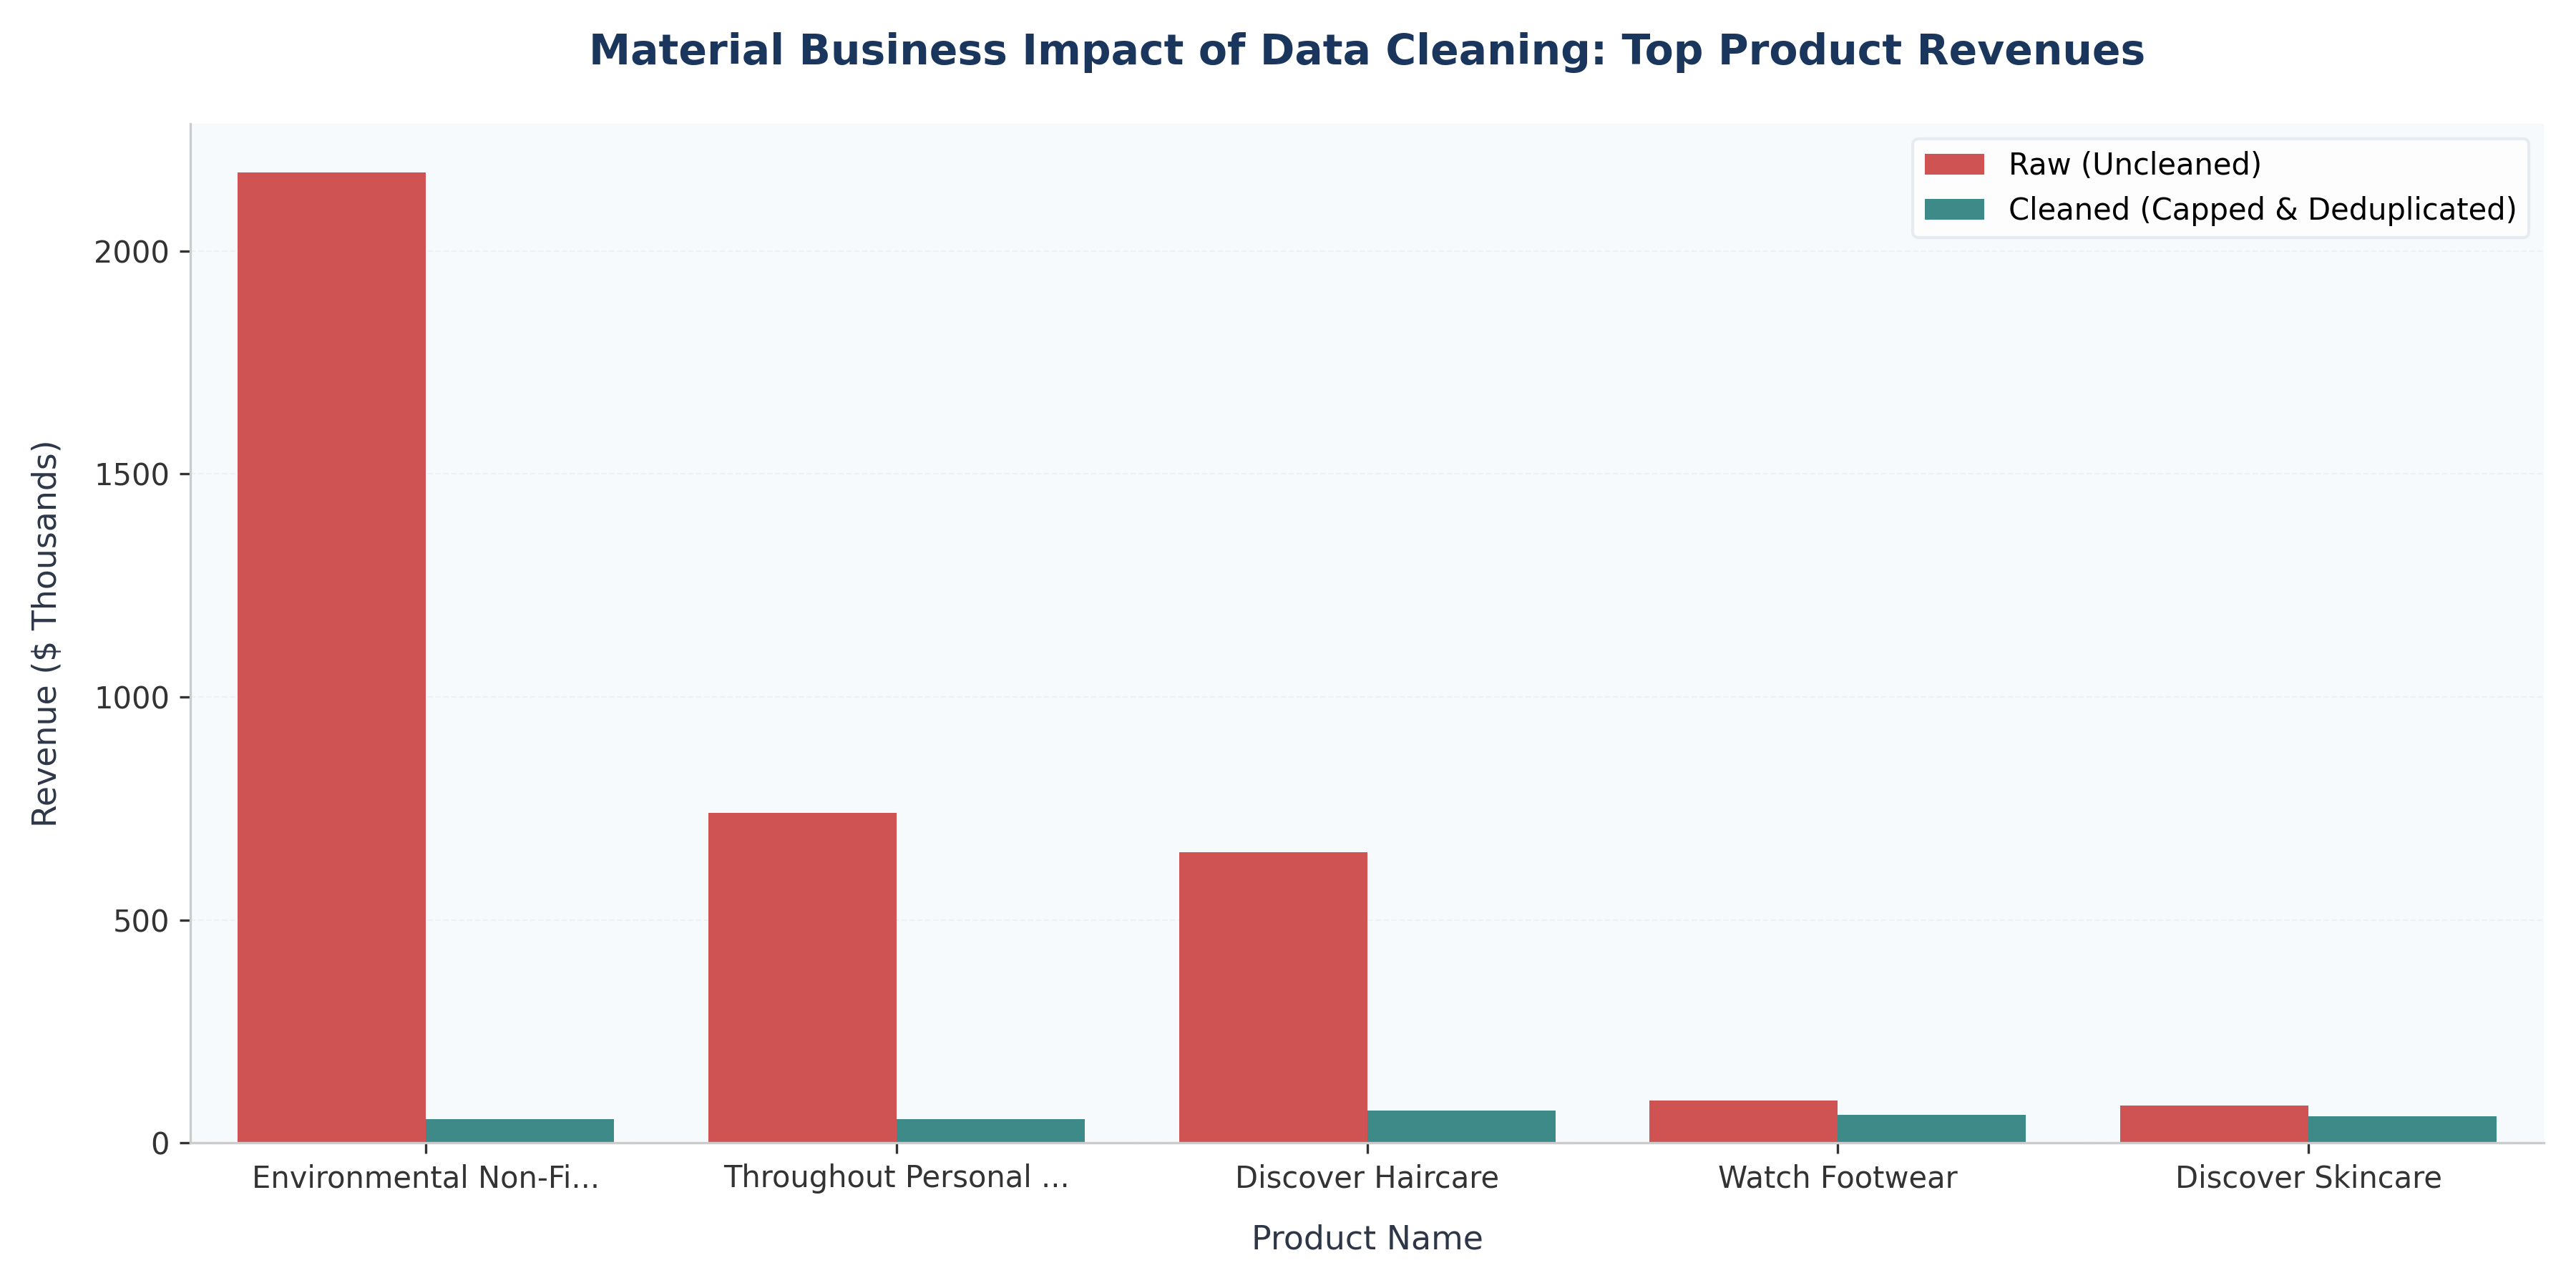

In [9]:
from IPython.display import Image, display

charts = [
    ("Chart 1: RFM Segment Revenue Contribution", "../figures/chart_1_rfm_revenue.png"),
    ("Chart 2: MoM Revenue Trend and Seasonality", "../figures/chart_2_monthly_trend.png"),
    ("Chart 3: Effective Profit Margin by Category", "../figures/chart_3_profit_margins.png"),
    ("Chart 4: Review Ratings vs. Repeat Purchase Rates", "../figures/chart_4_reviews_repeat_rate.png"),
    ("Chart 5: Device Type & Country Conversion Rate Heatmap", "../figures/chart_5_conversion_heatmap.png"),
    ("Chart 6: Revenue Forecasting with Uncertainty Bands", "../figures/chart_6_revenue_forecast.png"),
    ("Chart 7: Monte Carlo Stockout Demand Distributions", "../figures/chart_7_monte_carlo.png"),
    ("Chart 8: Data-Quality Impact (Raw vs Cleaned Data)", "../figures/chart_8_data_quality_impact.png")
]

for title, path in charts:
    print(f"\n{title}")
    display(Image(filename=path))
